# 🧱 Statistical Foundations
### Stage 1: The Framework Behind Every Test You'll Ever Run  |  ⏱️ ~40-minute session

---

Here's the trap most people fall into: they memorize "use a t-test here, use Chi-Square there" like a recipe book, without understanding *why* any of it works. Then the moment a new situation doesn't match a memorized recipe exactly, they're stuck.

This session fixes that. By the end, every test in Stages 2–7 will feel like a **variation on one single idea**, not a random new rule to memorize.

### The one idea underneath everything
> *"Could this result have happened just by random chance — or is something real going on?"*

Every hypothesis test, from a simple t-test to a full regression model, is just a structured way of answering that one question.

### Session map 

| Topic |
|---|
|  Hypothesis testing basics: H₀/H₁, p-value, α (courtroom analogy + live simulation) |
|  Type I & Type II errors (simulated, visually) |
|  Confidence intervals |
|  Types of data: nominal, ordinal, interval, ratio |
|  Parametric vs non-parametric — the big fork in the road |

We'll use `tips` and `penguins` from seaborn throughout, plus small simulations to make abstract ideas (like "what even is a p-value") visible and concrete.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print(tips.shape, penguins.shape)
tips.head()


(244, 7) (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ Hypothesis Testing Basics

### The courtroom analogy

Think of every statistical test as a **trial**:

| Courtroom | Statistics |
|---|---|
| Defendant is presumed innocent | **Null Hypothesis (H₀)**: "nothing special is happening" (no effect, no difference) |
| Prosecution must prove guilt | **Alternative Hypothesis (H₁)**: "something real is happening" (there IS an effect/difference) |
| Evidence presented | Your sample data |
| "Beyond reasonable doubt" threshold | **Significance level (α)** — usually 0.05 |
| Verdict | Reject H₀, or fail to reject H₀ |

Crucially: **we never "prove" H₀ is true.** Just like a "not guilty" verdict doesn't mean "proven innocent" — it means "not enough evidence to convict." Statistics works the same way: "fail to reject H₀" ≠ "H₀ is true."

### The p-value — the most misunderstood number in statistics

> **p-value** = the probability of seeing evidence *this extreme (or more)*, **if H₀ were actually true**.

It is **NOT**:
- ❌ The probability that H₀ is true
- ❌ The probability that your result is "due to chance" in some vague sense
- ❌ The probability you're wrong if you reject H₀

It IS:
- ✅ A measure of how surprising your data would be, *assuming* nothing real is going on

### Significance level (α)
This is the threshold **you choose in advance** — your tolerance for false alarms. The most common convention is **α = 0.05** (a 5% risk of wrongly rejecting a true H₀).

**Decision rule:**
- p-value ≤ α → Reject H₀ ("statistically significant")
- p-value > α → Fail to reject H₀ ("not statistically significant")

Let's make this concrete with a live simulation.


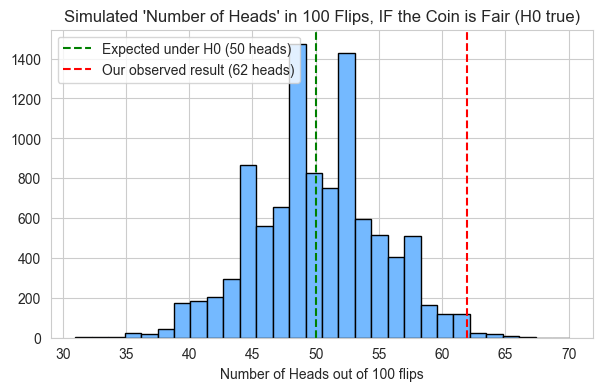

Simulated p-value: 0.0210
Exact binomial test p-value: 0.0210


In [2]:
# SIMULATION: What does a p-value actually look like?
# Imagine H0 is TRUE: a fair coin (50% heads). We flip it 100 times.
# We repeat this experiment 10,000 times and look at the distribution of "number of heads".

n_flips = 100
n_simulations = 10000

simulated_heads = np.random.binomial(n=n_flips, p=0.5, size=n_simulations)

fig, ax = plt.subplots()
ax.hist(simulated_heads, bins=30, color='#74b9ff', edgecolor='black')
ax.axvline(50, color='green', linestyle='--', label='Expected under H0 (50 heads)')
ax.axvline(62, color='red', linestyle='--', label='Our observed result (62 heads)')
ax.set_title("Simulated 'Number of Heads' in 100 Flips, IF the Coin is Fair (H0 true)")
ax.set_xlabel("Number of Heads out of 100 flips")
ax.legend()
plt.show()

# The p-value = how many of our 10,000 fair-coin simulations were AS EXTREME as 62 heads (two-sided)
observed = 62
p_value_sim = np.mean(np.abs(simulated_heads - 50) >= np.abs(observed - 50))
print(f"Simulated p-value: {p_value_sim:.4f}")

# Compare to the exact binomial test
exact_p = stats.binomtest(observed, n_flips, p=0.5).pvalue
print(f"Exact binomial test p-value: {exact_p:.4f}")


**What just happened:** we assumed the coin was fair (H₀ true), simulated 10,000 fair experiments, and asked *"in what fraction of those did we see a result at least as extreme as our actual 62 heads?"* That fraction **is** the p-value. It's simply "how surprising is my data, under the assumption that nothing special is going on."

With p ≈ 0.02–0.03 (< 0.05), we'd reject H₀ here — 62 heads out of 100 is unusual enough for a fair coin that we start suspecting the coin might be biased.


## 2️⃣ Type I & Type II Errors — the two ways a test can be wrong

No test is perfect. There are exactly two ways to make a mistake:

| | H₀ is actually True | H₀ is actually False |
|---|---|---|
| **You fail to reject H₀** | ✅ Correct! | ❌ Type II Error (False Negative) — probability = **β** |
| **You reject H₀** | ❌ Type I Error (False Positive) — probability = **α** | ✅ Correct! |

- **Type I Error:** You cry "wolf!" when there's no wolf. (Convict an innocent person.)
- **Type II Error:** You miss the wolf that's actually there. (Let a guilty person go free.)

There's a natural tension: making α smaller (fewer false alarms) tends to increase β (you miss more real effects) — unless you also increase your sample size. **Statistical power** = 1 − β = the probability of correctly detecting a real effect.

Let's simulate both error types directly.


In [3]:
# SIMULATION: Type I error rate
# H0 IS true here (both groups drawn from the SAME distribution).
# If we test at alpha=0.05, we SHOULD see a "significant" result about 5% of the time, purely by chance.

false_positives = 0
n_experiments = 2000

for _ in range(n_experiments):
    group_a = np.random.normal(loc=50, scale=10, size=30)
    group_b = np.random.normal(loc=50, scale=10, size=30)  # SAME true mean -> H0 is true
    _, p = stats.ttest_ind(group_a, group_b)
    if p < 0.05:
        false_positives += 1

print(f"Type I error rate observed: {false_positives / n_experiments:.4f}")
print("(Should be close to our chosen alpha = 0.05 -- purely random false alarms)")


Type I error rate observed: 0.0545
(Should be close to our chosen alpha = 0.05 -- purely random false alarms)


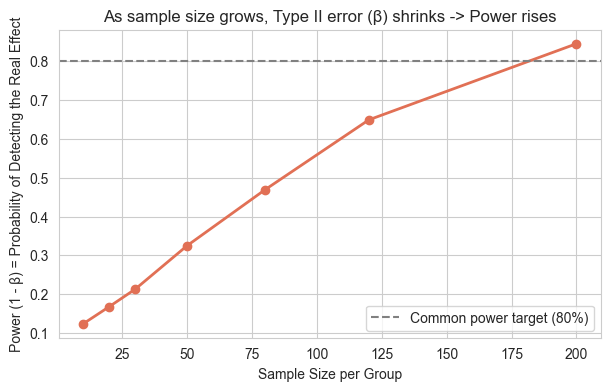

n=  10 per group -> Power = 0.12 (Type II error rate = 0.88)
n=  20 per group -> Power = 0.17 (Type II error rate = 0.83)
n=  30 per group -> Power = 0.21 (Type II error rate = 0.79)
n=  50 per group -> Power = 0.33 (Type II error rate = 0.68)
n=  80 per group -> Power = 0.47 (Type II error rate = 0.53)
n= 120 per group -> Power = 0.65 (Type II error rate = 0.35)
n= 200 per group -> Power = 0.84 (Type II error rate = 0.16)


In [4]:
# SIMULATION: Type II error rate & Power
# H0 is FALSE here (the two groups have genuinely different means).
# We check how often we correctly detect the difference vs. miss it, at different sample sizes.

def simulate_power(n_per_group, true_diff=3, n_experiments=1000):
    detections = 0
    for _ in range(n_experiments):
        group_a = np.random.normal(loc=50, scale=10, size=n_per_group)
        group_b = np.random.normal(loc=50 + true_diff, scale=10, size=n_per_group)
        _, p = stats.ttest_ind(group_a, group_b)
        if p < 0.05:
            detections += 1
    return detections / n_experiments

sample_sizes = [10, 20, 30, 50, 80, 120, 200]
powers = [simulate_power(n) for n in sample_sizes]

fig, ax = plt.subplots()
ax.plot(sample_sizes, powers, marker='o', color='#e17055', linewidth=2)
ax.axhline(0.8, color='gray', linestyle='--', label='Common power target (80%)')
ax.set_xlabel("Sample Size per Group")
ax.set_ylabel("Power (1 - β) = Probability of Detecting the Real Effect")
ax.set_title("As sample size grows, Type II error (β) shrinks -> Power rises")
ax.legend()
plt.show()

for n, pw in zip(sample_sizes, powers):
    print(f"n={n:>4} per group -> Power = {pw:.2f} (Type II error rate = {1-pw:.2f})")


**The takeaway:** with a small sample, you can easily miss a real effect (high Type II error / low power) — not because the effect isn't there, but because your test simply didn't have enough data to detect it reliably. This is *exactly* why "the study found no significant difference" doesn't always mean "there's no real difference" — it might just mean the study was underpowered.


## 3️⃣ Confidence Intervals — the companion to every p-value

A p-value tells you *whether* an effect is statistically detectable. A **confidence interval (CI)** tells you the **plausible range of values** for the true effect — much more informative for decision-making.

> A **95% confidence interval** means: *if we repeated this study many times, 95% of the intervals we'd construct this way would contain the true population value.*

(Common misreading to correct: it's **not** "there's a 95% chance the true value is in this specific interval" — the true value is fixed, it's our *method* that succeeds 95% of the time across repeated samples.)

### Practical: CI for average tip amount


In [5]:
tip_data = tips['tip']
mean_tip = tip_data.mean()
sem = stats.sem(tip_data)  # standard error of the mean
ci_low, ci_high = stats.t.interval(confidence=0.95, df=len(tip_data)-1, loc=mean_tip, scale=sem)

print(f"Sample mean tip: ${mean_tip:.2f}")
print(f"95% Confidence Interval: (${ci_low:.2f}, ${ci_high:.2f})")
print("Interpretation: we're 95% confident the TRUE average tip (for all customers, not just our sample)")
print("falls somewhere between these two values.")


Sample mean tip: $3.00
95% Confidence Interval: ($2.82, $3.17)
Interpretation: we're 95% confident the TRUE average tip (for all customers, not just our sample)
falls somewhere between these two values.


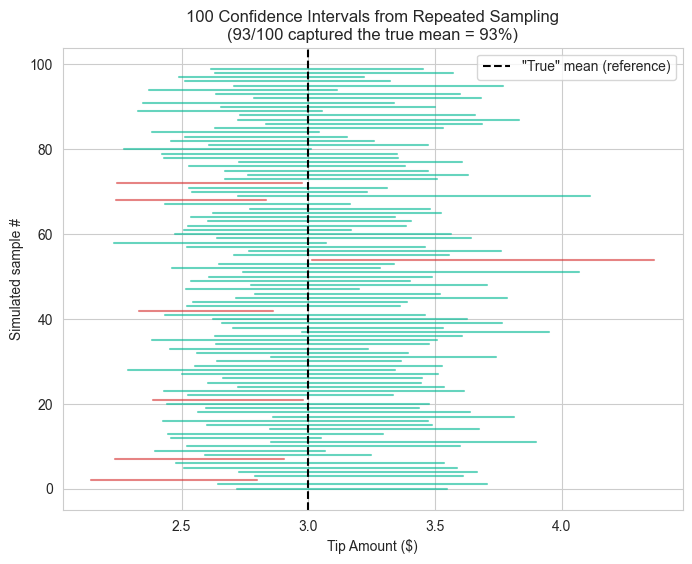

In [6]:
# Let's SEE what "95% of intervals capture the true mean" actually means with a simulation.
# Suppose the TRUE population mean tip is exactly our observed sample mean (as a stand-in for "ground truth").

true_mean = mean_tip
n_samples_to_draw = 100
sample_size = 40
captured = 0

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_samples_to_draw):
    sample = np.random.choice(tip_data, size=sample_size, replace=True)
    s_mean = sample.mean()
    s_sem = stats.sem(sample)
    low, high = stats.t.interval(0.95, df=sample_size-1, loc=s_mean, scale=s_sem)
    color = '#00b894' if (low <= true_mean <= high) else '#d63031'
    if low <= true_mean <= high:
        captured += 1
    ax.plot([low, high], [i, i], color=color, alpha=0.6)

ax.axvline(true_mean, color='black', linestyle='--', label='"True" mean (reference)')
ax.set_xlabel("Tip Amount ($)")
ax.set_ylabel("Simulated sample #")
ax.set_title(f"100 Confidence Intervals from Repeated Sampling\n({captured}/100 captured the true mean = {captured}%)")
ax.legend()
plt.show()


**What you should notice:** most (roughly 95%) of the green intervals capture the true mean; a few red ones (by chance) miss it. That's the entire meaning of "95% confidence" — it describes the **reliability of the method**, not a probability statement about any single interval you happen to compute.


## 4️⃣ Types of Data — this decides which test you're even allowed to use

Every variable falls into one of four measurement scales. This classification is not academic trivia — **it directly determines which statistical tests are valid** for that variable.

| Scale | Definition | Can you order it? | Are gaps meaningful? | True zero? | Examples |
|---|---|---|---|---|---|
| **Nominal** | Categories with no inherent order | ❌ | ❌ | ❌ | Sex, species, day of week |
| **Ordinal** | Categories WITH an order | ✅ | ❌ (gaps not equal) | ❌ | Satisfaction rating (1-5), education level |
| **Interval** | Numeric, equal gaps, NO true zero | ✅ | ✅ | ❌ | Temperature in °C, calendar year |
| **Ratio** | Numeric, equal gaps, true zero exists | ✅ | ✅ | ✅ | Height, weight, price, bill amount |

**Why it matters:** you can compute a meaningful mean for ratio/interval data. But you cannot meaningfully say the "average" of nominal categories like {Male, Female} — the appropriate summary there is a **count or proportion**, and the appropriate test is something like Chi-Square, not a t-test.

### Practical: classify the columns in our datasets


In [7]:
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [9]:
# TYPES of Test based on data types

#  Nominal   -> use Chi-Square (vs another category) or as a GROUPING variable for ANOVA/Kruskal-Wallis
# Ratio     -> t-test / ANOVA / correlation (numeric, true zero)


## 5️⃣ Parametric vs Non-Parametric — the big fork in the road

This is the master switch that determines which specific test you'll use in Stages 3 and 4.

| | Parametric | Non-Parametric |
|---|---|---|
| **Assumes** | Data follows a known distribution (usually normal) | No specific distribution assumed |
| **Works on** | Actual values (means, variances) | Ranks / order of values |
| **Statistical power** | Higher (when assumptions hold) | Slightly lower, but more robust |
| **When to use** | Normality confirmed (Stage 2), reasonably large/clean sample | Normality fails, small sample, ordinal data, outliers present |
| **Examples** | t-test, ANOVA, Pearson correlation | Mann-Whitney U, Kruskal-Wallis, Spearman correlation |

### The decision flow you'll use for the rest of this course

```
Got continuous data to compare across groups?
        │
        ├── Check normality (Shapiro-Wilk / Q-Q plot) -- Stage 2
        │        │
        │        ├── Normal?  ──► Use PARAMETRIC test  (Stage 3: t-test / ANOVA)
        │        │
        │        └── Not normal? ──► Use NON-PARAMETRIC test (Stage 4: Mann-Whitney / Kruskal-Wallis)
        │
        └── Got categorical data instead? ──► Chi-Square Test (Stage 5)
```

### Quick visual gut-check: normal vs skewed


In [10]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


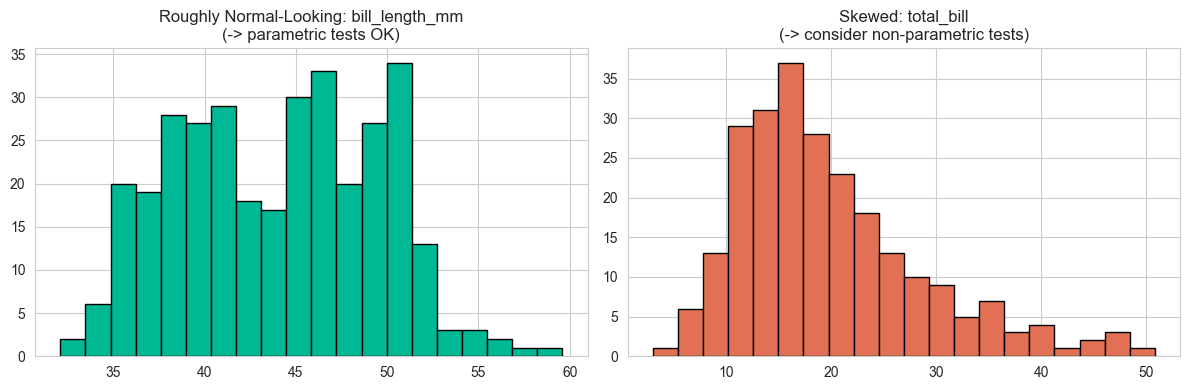

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A roughly normal variable (bill_depth_mm in penguins tends to be well-behaved)
# axes[0].hist(penguins['bill_depth_mm'], bins=20, color='#00b894', edgecolor='black')
axes[0].hist(penguins['bill_length_mm'], bins=20, color='#00b894', edgecolor='black')
axes[0].set_title("Roughly Normal-Looking: bill_length_mm\n(-> parametric tests OK)")

# A skewed variable (total_bill in tips is right-skewed)
axes[1].hist(tips['total_bill'], bins=20, color='#e17055', edgecolor='black')
axes[1].set_title("Skewed: total_bill\n(-> consider non-parametric tests)")

plt.tight_layout()
plt.show()


This single visual check — "does this look bell-shaped, or does it have a long tail / outliers?" — combined with the formal Shapiro-Wilk test from Stage 2, is what sends you down the parametric or non-parametric branch for every test in this course.


## 📋 Cheat Sheet — Stage 1 Recap

| Concept | One-line definition |
|---|---|
| **Null Hypothesis (H₀)** | The "nothing special is happening" baseline assumption |
| **Alternative Hypothesis (H₁)** | The "something real is happening" claim you're testing for |
| **p-value** | Probability of seeing data this extreme, IF H₀ were true |
| **Significance level (α)** | Your pre-chosen threshold for "surprising enough" (usually 0.05) |
| **Type I Error** | False positive — rejecting a true H₀ |
| **Type II Error** | False negative — failing to reject a false H₀ |
| **Power (1-β)** | Probability of correctly detecting a real effect |
| **Confidence Interval** | Plausible range for the true value, with a known long-run success rate |
| **Nominal / Ordinal / Interval / Ratio** | The 4 measurement scales — determine which tests are valid |
| **Parametric vs Non-parametric** | Whether a test assumes a known distribution (normal) or not |

